Analysis Notebook

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("../src"))

from herschel_bulkley_model import herschel_bulkley_shear_stress

Generate Rheology Curve

In [40]:
yield_stress = 6
K = 0.4
n = 0.65

shear_rates = np.linspace(0, 500, 120)

shear_stress = herschel_bulkley_shear_stress(
    yield_stress,
    K,
    n,
    shear_rates
)

Plot Rheology Curve

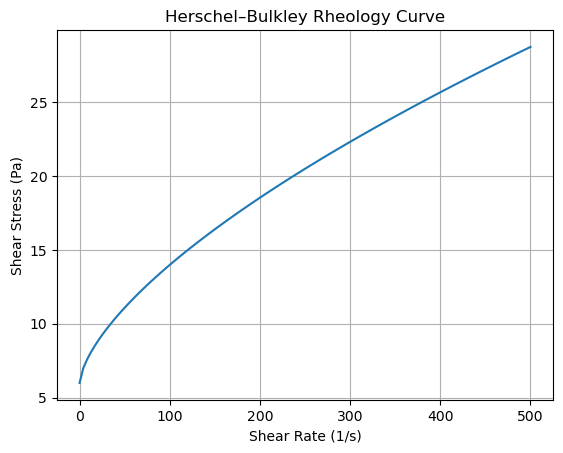

In [41]:
plt.figure()

plt.plot(shear_rates, shear_stress)

plt.xlabel("Shear Rate (1/s)")
plt.ylabel("Shear Stress (Pa)")
plt.title("Herschel–Bulkley Rheology Curve")

plt.grid(True)
plt.savefig("../results/herschel_bulkley_curve.png", dpi=300)
plt.show()

Update Notebook Imports

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("../src"))

from herschel_bulkley_model import (
    herschel_bulkley_shear_stress,
    temperature_adjusted_K
)

Define Surface Rheology

In [43]:
yield_stress = 6
K_surface = 0.45
n = 0.65

surface_temp = 30
activation_energy = 5000

Define Downhole Temperature

In [44]:
depth = 2500
geothermal_gradient = 0.03

downhole_temp = surface_temp + geothermal_gradient * depth

Compute Temperature-Adjusted K

In [45]:
K_downhole = temperature_adjusted_K(
    K_surface,
    activation_energy,
    surface_temp,
    downhole_temp
)

print("Surface K:", K_surface)
print("Downhole K:", K_downhole)

Surface K: 0.45
Downhole K: 0.30362351744708793


Generate Rheology Curves

In [46]:
shear_rates = np.linspace(1, 500, 120)

stress_surface = herschel_bulkley_shear_stress(
    yield_stress,
    K_surface,
    n,
    shear_rates
)

stress_downhole = herschel_bulkley_shear_stress(
    yield_stress,
    K_downhole,
    n,
    shear_rates
)

Plot Comparison

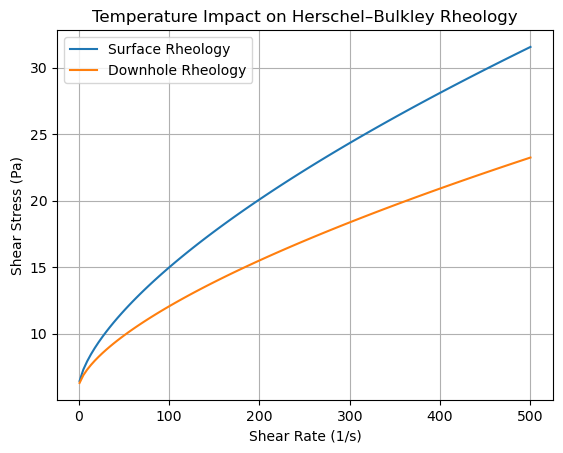

In [47]:
plt.figure()

plt.plot(shear_rates, stress_surface, label="Surface Rheology")
plt.plot(shear_rates, stress_downhole, label="Downhole Rheology")

plt.xlabel("Shear Rate (1/s)")
plt.ylabel("Shear Stress (Pa)")

plt.title("Temperature Impact on Herschel–Bulkley Rheology")

plt.legend()
plt.grid(True)
plt.savefig("../results/thermal_herschel_bulkley.png", dpi=300)
plt.show()

Update Notebook Imports

In [48]:
from herschel_bulkley_model import (
    apparent_viscosity_hb,
    annular_shear_rate,
    pressure_gradient_hb
)

Define Well Parameters and compute shear rate

In [49]:
flow_rate = 0.03        # m3/s
hole_diameter = 0.216   # 8.5 in
pipe_diameter = 0.127   # 5 in

shear_rate = annular_shear_rate(
    flow_rate,
    hole_diameter,
    pipe_diameter
)

print("Annular Shear Rate:", shear_rate)

Annular Shear Rate: 112.47272749024867


Compute Apparent Viscosity

In [50]:
mu_surface = apparent_viscosity_hb(
    yield_stress,
    K_surface,
    n,
    shear_rate
)   # for surface mud

mu_downhole = apparent_viscosity_hb(
    yield_stress,
    K_downhole,
    n,
    shear_rate
)   # for downhole mud

print("Surface Apparent Viscosity:", mu_surface)
print("Downhole Apparent Viscosity:", mu_downhole)
# mu_downhole < mu_surface since Hot mud flows easier.

Surface Apparent Viscosity: 0.13951425999135336
Downhole Apparent Viscosity: 0.11148544239330331


Compute Velocity

In [51]:
annular_area = np.pi * (hole_diameter**2 - pipe_diameter**2) / 4
velocity = flow_rate / annular_area

hydraulic_diameter = hole_diameter - pipe_diameter

Pressure Gradient

In [52]:
dp_surface = pressure_gradient_hb(
    mu_surface,
    velocity,
    hydraulic_diameter
) # for surface mud


dp_downhole = pressure_gradient_hb(
    mu_downhole,
    velocity,
    hydraulic_diameter
) # for downhole mud

print("Surface Pressure Gradient:", dp_surface)
print("Downhole Pressure Gradient:", dp_downhole)

# dp_downhole < dp_surface because viscosity dropped.

Surface Pressure Gradient: 705.2381728094917
Downhole Pressure Gradient: 563.55378792952


Compute ECD

In [53]:
mud_weight = 10.5
depth = 2500

ecd_surface = mud_weight + dp_surface * depth / (0.052 * depth)
ecd_downhole = mud_weight + dp_downhole * depth / (0.052 * depth)

print("Surface ECD:", ecd_surface)
print("Downhole ECD:", ecd_downhole)

# Now ECD reflects rheology changes.

Surface ECD: 13572.772554028688
Downhole ECD: 10848.072844798462


Import Both Models

In [54]:
sys.path.append(os.path.abspath(r"../../week_02_bingham_rheology\src"))

from bingham_model import calculate_bingham_parameters
from herschel_bulkley_model import apparent_viscosity_hb

Define Mud Rheology

In [55]:
theta600 = 45
theta300 = 30

PV, YP = calculate_bingham_parameters(theta600, theta300)

print("Plastic Viscosity:", PV)
print("Yield Point:", YP)

Plastic Viscosity: 15
Yield Point: 15


Convert Units

In [56]:
yield_stress = YP * 0.4788   # lb/100ft² → Pa
plastic_viscosity = PV / 1000
print(yield_stress)

7.182


Define Herschel–Bulkley Parameters

The correct rheology model for field data fitting is the Herschel–Bulkley model, fitted from multiple shear points.

But with only 600 and 300 rpm, we can approximate.

Step 1 — Compute Yield Stress

From Bingham:

YP = θ300 − PV

Your numbers:

PV = 15
YP = 15

Convert:

τy ≈ 7.18 Pa


Step 2 — Estimate Flow Behavior Index

Approximation:

n ≈ 3.32 * log10(θ600 / θ300)

Compute:

n ≈ 3.32 * log10(45 / 30)
n ≈ 0.58

This is realistic for drilling fluids.



Step 3 — Estimate Consistency Index

Use:

K = (τ300 − τy) / γ300ⁿ

Where:

γ300 ≈ 511 s⁻¹
τ300 = 30 * 0.4788 ≈ 14.36 Pa

So:

K ≈ 0.019 – 0.03

In [57]:
K = 0.025
n = 0.58

Compute Shear Rate

In [58]:
shear_rate = annular_shear_rate(
    flow_rate,
    hole_diameter,
    pipe_diameter
)
print(shear_rate)

112.47272749024867


Apparent Viscosity Comparison

In [59]:
mu_bingham = plastic_viscosity + (yield_stress / shear_rate) # Bingham plastic model

mu_hb = apparent_viscosity_hb(
    yield_stress,
    K,
    n,
    shear_rate
)     # Herschel–Bulkley model

print("Bingham Viscosity:", mu_bingham)
print("Herschel–Bulkley Viscosity:", mu_hb)

# HB < Bingham because HB captures shear thinning better.

Bingham Viscosity: 0.07885547999289584
Herschel–Bulkley Viscosity: 0.06729501847941954


Compute Pressure Gradient

In [60]:
dp_bingham = pressure_gradient_hb(
    mu_bingham,
    velocity,
    hydraulic_diameter
)   # Use your hydraulics function to calculate bingham pressure gradient


dp_hb = pressure_gradient_hb(
    mu_hb,
    velocity,
    hydraulic_diameter
)    # Use your hydraulics function to calculate Herschel–Bulkle pressure gradient

print("Pressure Gradient Bingham:", dp_bingham)
print("Pressure Gradient Herschel–Bulkley:", dp_hb)

Pressure Gradient Bingham: 398.610827521516
Pressure Gradient Herschel–Bulkley: 340.17322583761813


Compute ECD

In [61]:
mud_weight = 10.5
depth = 2500

ecd_bingham = mud_weight + dp_bingham / 0.052   # Bingham equation
ecd_hb = mud_weight + dp_hb / 0.052  # Herschel–Bulkley equation

print("ECD Bingham:", ecd_bingham)
print("ECD Herschel–Bulkley:", ecd_hb)

ECD Bingham: 7676.092836952231
ECD Herschel–Bulkley: 6552.29280456958


Plot Comparison

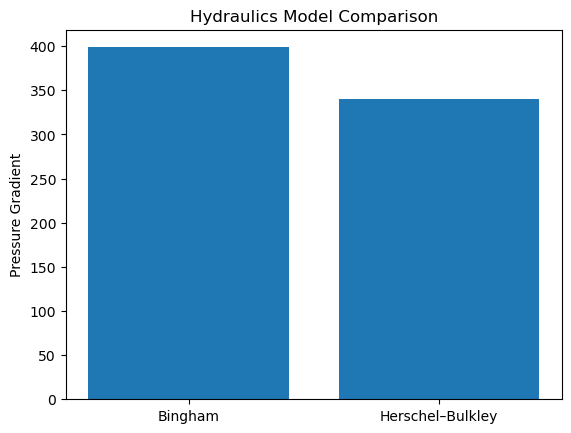

In [62]:
models = ["Bingham", "Herschel–Bulkley"]
pressure = [dp_bingham, dp_hb]

plt.bar(models, pressure)

plt.ylabel("Pressure Gradient")
plt.title("Hydraulics Model Comparison")
plt.savefig("../results/hydraulics_model_comparison.png", dpi=300)

plt.show()

Depth Range

In [63]:
depths = np.linspace(1, 3000, 120)

Temperature Profile

In [64]:
surface_temp = 30
Ea = 5000
geothermal_gradient = 0.03  # Use the geothermal gradient again.

temperatures = surface_temp + geothermal_gradient * depths

Store Results

In [65]:
ecd_profile = []
viscosity_profile = []
K_profile = []

Loop Through Depth

In [66]:
from herschel_bulkley_model import (
    herschel_bulkley_shear_stress,
    temperature_adjusted_K, 
    apparent_viscosity_hb,
    annular_shear_rate,
    pressure_gradient_hb
)


for depth, temp in zip(depths, temperatures):
    # K_downhole
    K_downhole = temperature_adjusted_K(
        K_surface,
        Ea,
        surface_temp,
        temp
    )

    K_profile.append(K_downhole)

    # viscosity_profile
    shear_rate = annular_shear_rate(
        flow_rate,
        hole_diameter,
        pipe_diameter
    )

    mu_app = apparent_viscosity_hb(
        yield_stress,
        K_downhole,
        n,
        shear_rate
    )

    viscosity_profile.append(mu_app)


    # ecd_profile
    annular_area = np.pi * (hole_diameter**2 - pipe_diameter**2) / 4
    velocity = flow_rate / annular_area

    hydraulic_diameter = hole_diameter - pipe_diameter

    dp_dz = pressure_gradient_hb(
        mu_app,
        velocity,
        hydraulic_diameter
    )    # this is annular pressure gradient( in psi_ft)


    mud_weight = 10.5 # in pounds per gallon
    # 1 Pa/m = 0.00004421 psi/ft
    dp_dz = dp_dz * 0.00004421 #  this line will convert dp_dz from pa/m to psi_ft 
    ecd = mud_weight + dp_dz / 0.052

    ecd_profile.append(ecd)

Plot ECD vs Depth

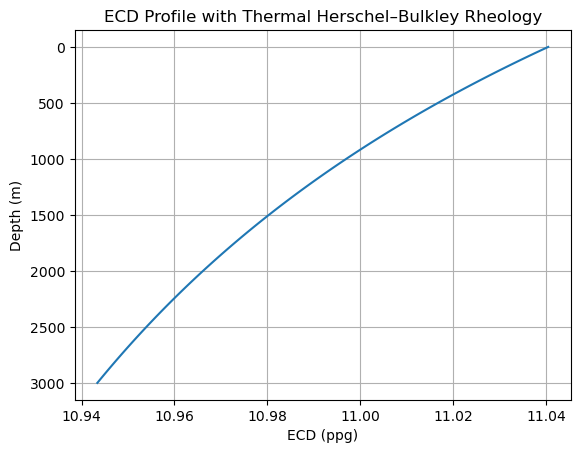

In [67]:
plt.figure()

plt.plot(ecd_profile, depths)

plt.gca().invert_yaxis()

plt.xlabel("ECD (ppg)")
plt.ylabel("Depth (m)")
plt.title("ECD Profile with Thermal Herschel–Bulkley Rheology")

plt.grid(True)
# plt.savefig("../results/ecd_depth_profile.png", dpi=300)
plt.show()

Plot Viscosity Change

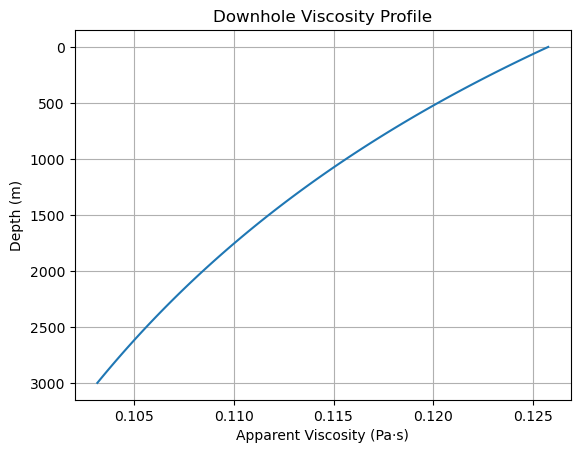

In [68]:
plt.figure()

plt.plot(viscosity_profile, depths)

plt.gca().invert_yaxis()

plt.xlabel("Apparent Viscosity (Pa·s)")
plt.ylabel("Depth (m)")
plt.title("Downhole Viscosity Profile")

plt.grid(True)

plt.show()  

# You should see viscosity decrease with depth because hot mud flows easier. 
 # useful for debugging the simulator.

Plot Consistency Index

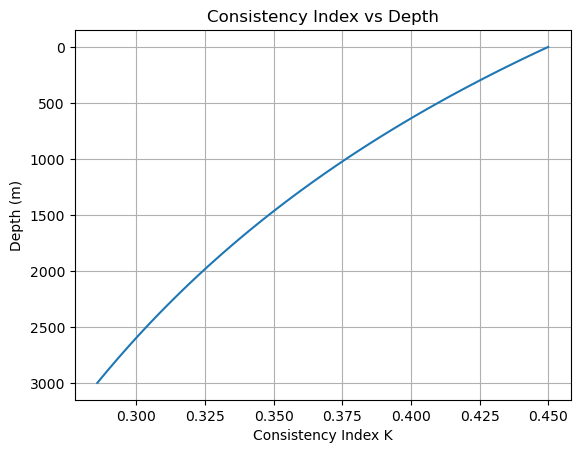

In [69]:
plt.figure()

plt.plot(K_profile, depths)

plt.gca().invert_yaxis()

plt.xlabel("Consistency Index K")
plt.ylabel("Depth (m)")
plt.title("Consistency Index vs Depth")

plt.grid(True)

plt.show()

Save Results and export CSV

In [70]:

import pandas as pd

results = pd.DataFrame({
    "Depth": depths,
    "Temperature": temperatures,
    "K": K_profile,
    "Viscosity": viscosity_profile,
    "ECD": ecd_profile
})

results.to_csv("../results/hb_depth_simulation.csv", index=False)

Compare Models through the whole wellbore

Prepare Storage

In [71]:
ecd_bingham_profile = []
ecd_hb_profile = []

Loop Through Depth

In [72]:
from bingham_temperature_model import (
    temperature_corrected_pv,
    temperature_corrected_yp
)



for depth, temp in zip(depths, temperatures):

    # HB temperature correction
    K_downhole = temperature_adjusted_K(
        K_surface,
        Ea,
        surface_temp,
        temp
    )

    shear_rate = annular_shear_rate(
        flow_rate,
        hole_diameter,
        pipe_diameter
    )

    # HB viscosity
    mu_hb = apparent_viscosity_hb(
        yield_stress,
        K_downhole,
        n,
        shear_rate
    )

    # Bingham viscosity temperature correction

    PV_downhole = temperature_corrected_pv(
    PV,
    surface_temp,
    temp
    )

    YP_downhole = temperature_corrected_yp(
    YP,
    surface_temp,
    temp
    )

    yield_stress_downhole = YP_downhole * 0.4788
    plastic_viscosity_downhole = PV_downhole / 1000

    mu_bingham = plastic_viscosity_downhole + yield_stress_downhole / shear_rate


    annular_area = np.pi * (hole_diameter**2 - pipe_diameter**2) / 4
    velocity = flow_rate / annular_area

    hydraulic_diameter = hole_diameter - pipe_diameter

    dp_hb = pressure_gradient_hb(
        mu_hb,
        velocity,
        hydraulic_diameter
    )

    dp_bingham = pressure_gradient_hb(
        mu_bingham,
        velocity,
        hydraulic_diameter
    )

    
    # Convert the SI gradients (Pa/m) to Field gradients (psi/ft)
    Pa_m_to_psi_ft = 0.00004421
    dp_hb_field = dp_hb * Pa_m_to_psi_ft
    dp_bingham_field = dp_bingham * Pa_m_to_psi_ft

    # Calculate ECD using the field values
    mud_weight = 10.5
    ecd_hb = mud_weight + (dp_hb_field / 0.052)
    ecd_bingham = mud_weight + (dp_bingham_field / 0.052)

    # Append to your profiles
    ecd_hb_profile.append(ecd_hb)
    ecd_bingham_profile.append(ecd_bingham)


Plot Model Comparison

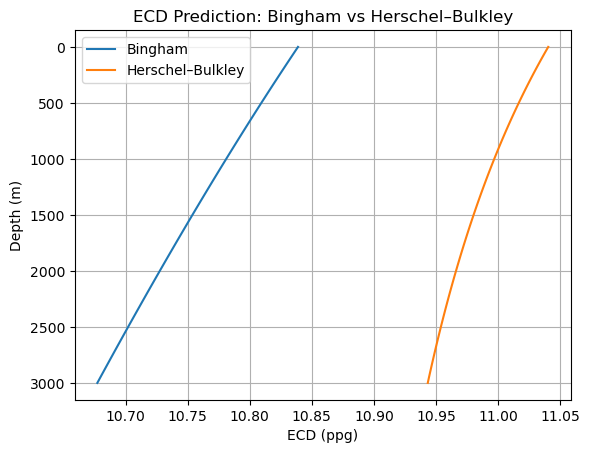

In [73]:
plt.figure()

plt.plot(ecd_bingham_profile, depths, label="Bingham")
plt.plot(ecd_hb_profile, depths, label="Herschel–Bulkley")

plt.gca().invert_yaxis()

plt.xlabel("ECD (ppg)")
plt.ylabel("Depth (m)")

plt.title("ECD Prediction: Bingham vs Herschel–Bulkley")

plt.legend()
plt.grid(True)

plt.show()

Save Results

In [74]:
results = pd.DataFrame({
    "Depth": depths,
    "ECD_Bingham": ecd_bingham_profile,
    "ECD_HB": ecd_hb_profile
})

results.to_csv("../results/model_comparison.csv", index=False)